<a href="https://colab.research.google.com/github/f3r21/actas-cnn/blob/main/notebooks/01_preprocesamiento_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# actas-cnn — Preprocesamiento (Colab)

**Que hace:** baja las actas (PDFs) + labels de Hugging Face, las renderiza, detecta los digitos, recorta y etiqueta, arma los manifests y **publica el bundle de crops en HF** para que el notebook entregable lo consuma.

**Esta es la superficie que mas se itera:** para cambiar *como se detectan los digitos*, edita la celda marcada `PREPROCESAMIENTO`, pon `REHACER_DESDE_CERO = True` en la config y vuelve a correr todo (sin el flag, las actas ya procesadas se saltan y publicarias crops del metodo viejo).

**Como correr:** runtime **CPU normal** (NO actives GPU: este notebook no la usa y Colab desconecta runtimes con GPU ociosa a mitad del procesamiento). Pon el `HF_TOKEN` (permiso de escritura) en el panel de secretos de Colab **antes** de correr: la subida final lo necesita. Luego Run all. Si la sesion se corta pero la VM sigue viva, re-correr todo continua donde quedo; si Colab recicla la VM, `/content` se pierde y la corrida empieza de cero.

## 0. Setup

In [1]:
# Dependencias (Colab ya trae torch, torchvision, numpy, pandas, matplotlib)
%pip install -q pymupdf==1.27.2.3 opencv-python-headless huggingface_hub pyarrow
print("deps instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 89.7 MB/s eta 0:00:00
deps instaladas


In [2]:
# === Config + entorno ===
import os, tarfile
from pathlib import Path
import pandas as pd
# Este notebook es CPU-only (PyMuPDF/PIL/pandas, la GPU jamas se usa).
# NO pidas runtime GPU: Colab desconecta runtimes con GPU ociosa a mitad de la
# celda larga de render ("Runtime disconnected"). Usa el runtime CPU normal.

HF_DATASET_REPO = "f3r21/actas-cnn-dataset"   # PDFs + labels (+ crops_bundle si 01 ya corrio)

WORK = Path("/content") if Path("/content").exists() else Path(".").resolve()
DATA = WORK / "data"; DATA.mkdir(parents=True, exist_ok=True)
N_ACTAS = 5000   # cuantas actas preprocesar
SUBIR_A_HF = True  # publica crops_bundle.tar.gz en HF (requiere HF_TOKEN)
# True si editaste la deteccion de digitos: borra crops y progreso y reprocesa
# todo. Sin esto, re-correr salta las actas ya hechas (publicarias crops viejos).
REHACER_DESDE_CERO = False
if SUBIR_A_HF:
    from huggingface_hub import get_token
    if get_token() is None:
        # Avisar AHORA y no tras horas de procesamiento, cuando fallaria la subida.
        print("AVISO: no hay HF_TOKEN (panel de secretos de Colab, icono de la llave; "
              "dale acceso a este notebook). Configuralo antes de la celda final "
              "o pon SUBIR_A_HF=False.")

AVISO: no hay HF_TOKEN (panel de secretos de Colab, icono de la llave; dale acceso a este notebook). Configuralo antes de la celda final o pon SUBIR_A_HF=False.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
# Plantilla Presidencial: 42 campos (38 partidos + blanco/nulos/impugnados + total).
# Cajas en fraccion [0,1]; embebida para que el notebook sea autonomo.
TEMPLATE = { "descripcion": "ACTA DE ESCRUTINIO PRESIDENCIAL (idEleccion=10, tipo=1). iter7 auto-detected.", "image_size_reference": [ 2339, 3309 ], "fields": [ { "name": "partido_01", "box": [ 0.462, 0.2149, 0.539, 0.2315 ], "n_digits": 3 }, { "name": "partido_02", "box": [ 0.462, 0.2315, 0.539, 0.2481 ], "n_digits": 3 }, { "name": "partido_03", "box": [ 0.462, 0.2481, 0.539, 0.2648 ], "n_digits": 3 }, { "name": "partido_04", "box": [ 0.462, 0.2648, 0.539, 0.2814 ], "n_digits": 3 }, { "name": "partido_05", "box": [ 0.462, 0.2814, 0.539, 0.298 ], "n_digits": 3 }, { "name": "partido_06", "box": [ 0.462, 0.298, 0.539, 0.3146 ], "n_digits": 3 }, { "name": "partido_07", "box": [ 0.462, 0.3146, 0.539, 0.3312 ], "n_digits": 3 }, { "name": "partido_08", "box": [ 0.462, 0.3312, 0.539, 0.3479 ], "n_digits": 3 }, { "name": "partido_09", "box": [ 0.462, 0.3479, 0.539, 0.3645 ], "n_digits": 3 }, { "name": "partido_10", "box": [ 0.462, 0.3645, 0.539, 0.3811 ], "n_digits": 3 }, { "name": "partido_11", "box": [ 0.462, 0.3811, 0.539, 0.3977 ], "n_digits": 3 }, { "name": "partido_12", "box": [ 0.462, 0.3977, 0.539, 0.4143 ], "n_digits": 3 }, { "name": "partido_13", "box": [ 0.462, 0.4143, 0.539, 0.431 ], "n_digits": 3 }, { "name": "partido_14", "box": [ 0.462, 0.431, 0.539, 0.4476 ], "n_digits": 3 }, { "name": "partido_15", "box": [ 0.462, 0.4476, 0.539, 0.4642 ], "n_digits": 3 }, { "name": "partido_16", "box": [ 0.462, 0.4642, 0.539, 0.4808 ], "n_digits": 3 }, { "name": "partido_17", "box": [ 0.462, 0.4808, 0.539, 0.4974 ], "n_digits": 3 }, { "name": "partido_18", "box": [ 0.462, 0.4974, 0.539, 0.5141 ], "n_digits": 3 }, { "name": "partido_19", "box": [ 0.462, 0.5141, 0.539, 0.5307 ], "n_digits": 3 }, { "name": "partido_20", "box": [ 0.462, 0.5307, 0.539, 0.5473 ], "n_digits": 3 }, { "name": "partido_21", "box": [ 0.462, 0.5473, 0.539, 0.5639 ], "n_digits": 3 }, { "name": "partido_22", "box": [ 0.462, 0.5639, 0.539, 0.5805 ], "n_digits": 3 }, { "name": "partido_23", "box": [ 0.462, 0.5805, 0.539, 0.5972 ], "n_digits": 3 }, { "name": "partido_24", "box": [ 0.462, 0.5972, 0.539, 0.6138 ], "n_digits": 3 }, { "name": "partido_25", "box": [ 0.462, 0.6138, 0.539, 0.6304 ], "n_digits": 3 }, { "name": "partido_26", "box": [ 0.462, 0.6304, 0.539, 0.647 ], "n_digits": 3 }, { "name": "partido_27", "box": [ 0.462, 0.647, 0.539, 0.6636 ], "n_digits": 3 }, { "name": "partido_28", "box": [ 0.462, 0.6636, 0.539, 0.6803 ], "n_digits": 3 }, { "name": "partido_29", "box": [ 0.462, 0.6803, 0.539, 0.6969 ], "n_digits": 3 }, { "name": "partido_30", "box": [ 0.462, 0.6969, 0.539, 0.7135 ], "n_digits": 3 }, { "name": "partido_31", "box": [ 0.462, 0.7135, 0.539, 0.7301 ], "n_digits": 3 }, { "name": "partido_32", "box": [ 0.462, 0.7301, 0.539, 0.7467 ], "n_digits": 3 }, { "name": "partido_33", "box": [ 0.462, 0.7467, 0.539, 0.7634 ], "n_digits": 3 }, { "name": "partido_34", "box": [ 0.462, 0.7634, 0.539, 0.78 ], "n_digits": 3 }, { "name": "partido_35", "box": [ 0.462, 0.78, 0.539, 0.7966 ], "n_digits": 3 }, { "name": "partido_36", "box": [ 0.462, 0.7966, 0.539, 0.8132 ], "n_digits": 3 }, { "name": "partido_37", "box": [ 0.462, 0.8132, 0.539, 0.8298 ], "n_digits": 3 }, { "name": "partido_38", "box": [ 0.462, 0.8298, 0.539, 0.8465 ], "n_digits": 3 }, { "name": "votos_blanco", "box": [ 0.462, 0.8465, 0.539, 0.8631 ], "n_digits": 3 }, { "name": "votos_nulos", "box": [ 0.462, 0.8631, 0.539, 0.8797 ], "n_digits": 3 }, { "name": "votos_impugnados", "box": [ 0.462, 0.8797, 0.539, 0.8963 ], "n_digits": 3 }, { "name": "total_ciudadanos", "box": [ 0.4363, 0.8963, 0.539, 0.913 ], "n_digits": 4 } ] }

## 1. PREPROCESAMIENTO — deteccion de digitos (editar aqui)

In [4]:
# === PREPROCESAMIENTO: deteccion de digitos (EDITAR AQUI para cambiar el metodo) ===
# Metodo OFICIAL = zonal por plantilla: cada campo se recorta por su caja relativa
# y se parte en n_digits celdas equiespaciadas. La afin del template alinea bien
# en >98% de actas. Para cambiar "donde estan los digitos", reescribe crop_fields
# / split_digits (p.ej. projection profile, deteccion por contornos, un detector
# aprendido) manteniendo la firma: localizar -> {campo: [celda_0, celda_1, ...]}.
import fitz  # PyMuPDF
from PIL import Image

TARGET_SIZE = (2339, 3309)  # tamano fijo: imagenes uniformes, detector estable

def rasterize_acta(pdf_path):
    """PDF de acta -> PIL.Image en gris (primera pagina, tamano fijo), en memoria.
    Sin PNG intermedio: encode+write+decode de un PNG de 7.7Mpx cuesta ~3/4 del
    tiempo por acta (medido en M2: 0.75s de 0.97s) y el archivo se borraria
    igual. Pixeles identicos al PNG (verificado byte a byte)."""
    with fitz.open(pdf_path) as doc:
        page = doc[0]
        if page.rect.width > page.rect.height:
            page.set_rotation(90)  # normaliza landscape -> portrait
        mat = fitz.Matrix(TARGET_SIZE[0] / page.rect.width,
                          TARGET_SIZE[1] / page.rect.height)
        pix = page.get_pixmap(matrix=mat)
    return Image.frombytes("RGB", (pix.width, pix.height), pix.samples).convert("L")

def render_acta(pdf_path, out_dir):
    """PDF de acta -> PNG portrait en disco (solo para QA visual / demo)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{Path(pdf_path).stem}_p0.png"
    rasterize_acta(pdf_path).save(out)
    return out

def crop_fields(image, template):
    """Recorta los 42 campos por sus cajas relativas [x0,y0,x1,y1] en [0,1].
    Acepta una PIL.Image ya rasterizada o una ruta a PNG."""
    img = image if isinstance(image, Image.Image) else Image.open(image).convert("L")
    w, h = img.size
    out = {}
    for field in template["fields"]:
        x0, y0, x1, y1 = field["box"]
        out[field["name"]] = img.crop((int(x0 * w), int(y0 * h),
                                       int(x1 * w), int(y1 * h)))
    return out

def split_digits(field_img, n_digits):
    """Parte un campo en n_digits celdas equiespaciadas (izq -> der)."""
    w, h = field_img.size
    step = w / n_digits
    return [field_img.crop((int(i * step), 0, int((i + 1) * step), h))
            for i in range(n_digits)]

def localize_digits(image, template):
    """Localizador zonal: {campo: [celda_0, ...]}. Punto unico de 'donde estan'."""
    fields = crop_fields(image, template)
    return {f["name"]: split_digits(fields[f["name"]], f["n_digits"])
            for f in template["fields"]}

In [5]:
# === Labels desde el ground truth ONPE + armado de crops/manifest ===
import csv
import pandas as pd

def es_celda_escrita(value, n_cells, pos):
    """Convencion ONPE: cifras right-justified, leading zeros en blanco.
    value=5,n=3 -> [vacio,vacio,'5']; value=0 -> todo vacio (nadie escribe '000')."""
    if value == 0:
        return False
    return pos >= n_cells - len(str(int(value)))

def int_to_digits(value, n_cells):
    """Entero -> lista de n_cells digitos right-justified. 18,3 -> [0,1,8]."""
    return [int(c) for c in str(int(value)).zfill(n_cells)]

def field_value_for(name, votos_acta, total_emitidos):
    """Entero del ground truth para un campo (partido / blanco-nulos-impugnados / total)."""
    if name.startswith("partido_"):
        pos = int(name.split("_")[1])
        row = votos_acta[votos_acta["nposicion"] == pos]
        return int(row.iloc[0]["nvotos"]) if len(row) else 0
    mapping = {"votos_blanco": 80, "votos_nulos": 81, "votos_impugnados": 82}
    if name in mapping:
        row = votos_acta[votos_acta["nposicion"] == mapping[name]]
        return int(row.iloc[0]["nvotos"]) if len(row) else 0
    if name == "total_ciudadanos":
        return int(total_emitidos)
    raise ValueError(name)

def build_crops_for_acta(image, archivo_id, id_acta, template,
                         votos, cabecera, crops_root, filtrar_vacias=True):
    """Imagen (PIL o ruta) + labels -> crops/<label>/<archivoId>_<campo>_c<pos>.png.
    Devuelve (guardados, filtrados)."""
    cab = cabecera[cabecera["idActa"] == id_acta]
    if len(cab) == 0 or pd.isna(cab.iloc[0]["totalVotosEmitidos"]):
        return 0, 0
    total = int(cab.iloc[0]["totalVotosEmitidos"])
    votos_acta = votos[votos["idActa"] == id_acta]
    cells = localize_digits(image, template)
    crops_root = Path(crops_root)
    n_saved = n_filt = 0
    for field in template["fields"]:
        name, n_cells = field["name"], field["n_digits"]
        value = field_value_for(name, votos_acta, total)
        labels = int_to_digits(value, n_cells)
        for pos, (label, dimg) in enumerate(zip(labels, cells[name])):
            if filtrar_vacias and not es_celda_escrita(value, n_cells, pos):
                n_filt += 1; continue
            d = crops_root / str(label); d.mkdir(parents=True, exist_ok=True)
            dimg.save(d / f"{archivo_id}_{name}_c{pos}.png")
            n_saved += 1
    return n_saved, n_filt

def build_manifest(crops_dir, out_csv):
    """crops/<label>/*.png -> manifest CSV (path,label) relativo a crops_dir."""
    crops_dir = Path(crops_dir); rows = []
    for label_dir in sorted(crops_dir.iterdir()):
        if label_dir.is_dir():
            for img in sorted(label_dir.glob("*.png")):
                rows.append((str(img.relative_to(crops_dir)), label_dir.name))
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["path", "label"]); w.writerows(rows)
    return len(rows)

## 2. Labels, universo y descarga de PDFs

Descarga **en una sola pasada paralela** (`snapshot_download`, una barra de progreso) en vez de 5000 descargas con 5000 barras, que congelan el front-end de Colab. Con `HF_TOKEN` puesto va mas rapido (sin rate-limit de anonimo).

In [6]:
import random, logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)  # 1 aviso, no 5000
from huggingface_hub import snapshot_download, list_repo_files
snapshot_download(HF_DATASET_REPO, repo_type="dataset", allow_patterns="labels/*",
                  local_dir=str(DATA))
archivos = pd.read_parquet(DATA / "labels/actas_archivos.parquet")
votos    = pd.read_parquet(DATA / "labels/actas_votos.parquet")
cabecera = pd.read_parquet(DATA / "labels/actas_cabecera.parquet")
# Universo = PDFs realmente publicados en el dataset. El parquet actas tiene ~84k
# presidenciales, pero solo se subieron las 5000 manuscritas; seleccionar del
# parquet pediria PDFs inexistentes (404). list_repo_files da exactamente lo subido.
con_label = set(archivos["archivoId"])
ids = sorted(f[:-4] for f in list_repo_files(HF_DATASET_REPO, repo_type="dataset")
             if f.endswith(".pdf") and f[:-4] in con_label)
random.Random(42).shuffle(ids)
ids = ids[:N_ACTAS]
n = len(ids); ntr = int(n * 0.70); nva = int(n * 0.15)
splits = {"train": ids[:ntr], "val": ids[ntr:ntr + nva], "test": ids[ntr + nva:]}
print({k: len(v) for k, v in splits.items()})

pdf_dir = WORK / "pdfs"; pdf_dir.mkdir(exist_ok=True)
snapshot_download(HF_DATASET_REPO, repo_type="dataset",
                  allow_patterns=[f"{a}.pdf" for a in ids], local_dir=str(pdf_dir))
print(f"{len(ids)} PDFs descargados")

Fetching ... files: 0it [00:00, ?it/s]

{'train': 3500, 'val': 750, 'test': 750}


Fetching ... files: 0it [00:00, ?it/s]

5000 PDFs descargados


## 3. Render + recorte + manifests (en memoria, paralelo, reanudable)

Por cada acta: rasteriza el PDF **directo a imagen en memoria** (el PNG intermedio costaba ~3/4 del tiempo por acta en encode/decode — medido 0.75s de 0.97s en M2 — y se borraba un segundo despues; los pixeles son identicos) y guarda solo los crops (~600MB). Corre en paralelo con todos los nucleos y es **reanudable dentro de la misma VM**: las actas ya procesadas (`data/procesadas_<split>.txt`) se saltan al re-correr la celda (si Colab recicla la VM, `/content` se pierde y se empieza de cero). Si editaste la deteccion de digitos, pon `REHACER_DESDE_CERO = True` en la config para no reusar crops del metodo viejo.

In [7]:
import shutil
from functools import partial
from multiprocessing import get_context
from tqdm.auto import tqdm

if REHACER_DESDE_CERO:
    for split in splits:
        shutil.rmtree(DATA / f"crops_{split}", ignore_errors=True)
        (DATA / f"procesadas_{split}.txt").unlink(missing_ok=True)
    print("REHACER_DESDE_CERO: crops y progreso borrados, se reprocesa todo")

aid_to_idacta = dict(zip(archivos["archivoId"], archivos["idActa"]))
# Restringir labels a las actas elegidas: acelera los joins por idActa del recorte.
sel_idactas = {int(aid_to_idacta[a]) for a in ids if a in aid_to_idacta}
votos    = votos[votos["idActa"].isin(sel_idactas)]
cabecera = cabecera[cabecera["idActa"].isin(sel_idactas)]

def procesa_acta(aid, croot):
    """Una acta end-to-end: rasteriza en memoria, recorta y guarda sus crops."""
    try:
        pdf = pdf_dir / f"{aid}.pdf"
        if not pdf.exists():
            return aid, 0, "pdf no descargado"
        img = rasterize_acta(pdf)
        ns, _ = build_crops_for_acta(img, aid, int(aid_to_idacta[aid]),
                                     TEMPLATE, votos, cabecera, croot)
        return aid, ns, None
    except Exception as e:  # un PDF malo no debe tumbar la corrida entera
        return aid, 0, repr(e)

NPROC = os.cpu_count() or 2
for split, sids in splits.items():
    croot = DATA / f"crops_{split}"
    done_file = DATA / f"procesadas_{split}.txt"
    hechas = set(done_file.read_text().split()) if done_file.exists() else set()
    pend = [a for a in sids if a not in hechas]
    saved, errores = 0, []
    if pend:
        with get_context("fork").Pool(NPROC) as pool, open(done_file, "a") as marca:
            tareas = pool.imap_unordered(partial(procesa_acta, croot=croot), pend)
            for aid, ns, err in tqdm(tareas, total=len(pend), desc=split):
                saved += ns
                if err:
                    errores.append((aid, err))
                else:
                    marca.write(aid + "\n"); marca.flush()
    n_rows = build_manifest(croot, DATA / f"manifest_{split}.csv")
    print(f"{split}: +{saved} crops ({len(hechas)} actas ya estaban hechas), "
          f"manifest {n_rows} filas, {len(errores)} errores")
    for aid, err in errores[:5]:
        print(f"  ERROR {aid}: {err}")

train:   0%|          | 0/3500 [00:00<?, ?it/s]

train: +106123 crops (0 actas ya estaban hechas), manifest 106123 filas, 0 errores


val:   0%|          | 0/750 [00:00<?, ?it/s]

val: +22876 crops (0 actas ya estaban hechas), manifest 22876 filas, 0 errores


test:   0%|          | 0/750 [00:00<?, ?it/s]

test: +22955 crops (0 actas ya estaban hechas), manifest 22955 filas, 0 errores


## 4. Demostracion: desde una acta hasta los digitos

Visualiza el resultado de la deteccion sobre una acta: los 42 campos localizados y, dentro de uno, las celdas de cada digito.

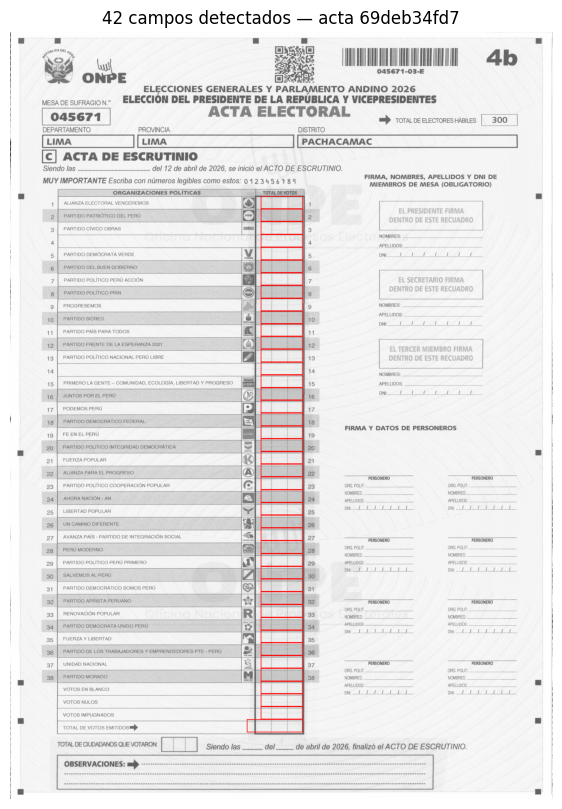

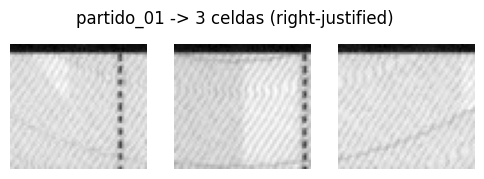

In [8]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

rendered = WORK / "rendered"; rendered.mkdir(exist_ok=True)
demo_aid = ids[0]
demo_png = render_acta(pdf_dir / f"{demo_aid}.pdf", rendered)
img = Image.open(demo_png).convert("RGB"); draw = ImageDraw.Draw(img); w, h = img.size
for f in TEMPLATE["fields"]:
    x0, y0, x1, y1 = f["box"]
    draw.rectangle([x0 * w, y0 * h, x1 * w, y1 * h], outline=(255, 0, 0), width=3)
plt.figure(figsize=(7, 10)); plt.imshow(img); plt.axis("off")
plt.title(f"42 campos detectados — acta {demo_aid[:10]}"); plt.show()

celdas = localize_digits(demo_png, TEMPLATE)
fig, axs = plt.subplots(1, 3, figsize=(6, 2))
for ax, c in zip(axs, celdas["partido_01"]):
    ax.imshow(c, cmap="gray"); ax.axis("off")
fig.suptitle("partido_01 -> 3 celdas (right-justified)"); plt.show()

## 5. Empaquetar y publicar el bundle de crops en HF

El notebook del modelo (`02_modelo_colab.ipynb`) baja este `crops_bundle.tar.gz`.

In [9]:
bundle = WORK / "crops_bundle.tar.gz"
with tarfile.open(bundle, "w:gz") as t:
    for split in ("train", "val", "test"):
        t.add(DATA / f"crops_{split}", arcname=f"data/crops_{split}")
        t.add(DATA / f"manifest_{split}.csv", arcname=f"data/manifest_{split}.csv")
print("bundle:", bundle, round(bundle.stat().st_size / 1e6, 1), "MB")

if SUBIR_A_HF:
    from huggingface_hub import HfApi
    api = HfApi()  # token: HF_TOKEN del entorno o del panel de secretos de Colab
    api.upload_file(path_or_fileobj=str(bundle), path_in_repo="crops_bundle.tar.gz",
                    repo_id=HF_DATASET_REPO, repo_type="dataset")
    print("subido a", HF_DATASET_REPO)
else:
    print("SUBIR_A_HF=False: el bundle quedo local. Ponlo en True (con HF_TOKEN) para publicar.")

bundle: /content/crops_bundle.tar.gz 345.6 MB


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6a28f04c-4d40e4107d0ad2dc132195c6;6c15b920-1581-471a-9970-35e678b18804)

Repository Not Found for url: https://huggingface.co/api/datasets/f3r21/actas-cnn-dataset/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.

---
Listo. Con el bundle publicado, abre **`02_modelo_colab.ipynb`** para entrenar y obtener las metricas finales.